# Libraries

In [2]:
import pandas as pd 

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

import sklearn as sk

import statsmodels.api as sm 

from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')

In [3]:
#  Loading the dataset


stock_original = pd.read_csv(r"C:\Users\DELL\Downloads\2) Stock Prices Data Set.csv")
stock_copied = stock_original
stock_copied.head(5)

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [5]:
# Converting date to datetime and sorting


stock_copied['date'] = pd.to_datetime(stock_copied['date'])
stock_copied_sort = stock_copied.sort_values('date')


print("Dataset loaded!")
print('Date range:', stock_copied['date'].min(), 'to', stock_copied['date'].max())
print("Unique stocks:",stock_copied['symbol'].nunique())


Dataset loaded!
Date range: 2014-01-02 00:00:00 to 2017-12-29 00:00:00
Unique stocks: 505


In [ ]:
# Focusing on AAPL trend


aapl = stock_copied[stock_copied['symbol'] == 'AAPL'].copy()
aapl =  aapl.set_index('date')
close = aapl['close']

print(f"\nAAPL data points: {len(close)}")
print(f"Starting price (2014-01-02: ${close.iloc[0]:.2f})")
print(f"Ending price (2017-12-29: ${close.iloc[-1]:.2f})")


AAPL data points: 1007
Starting price (2014-01-02: $79.02)
Ending price (2017-12-29: $169.23)


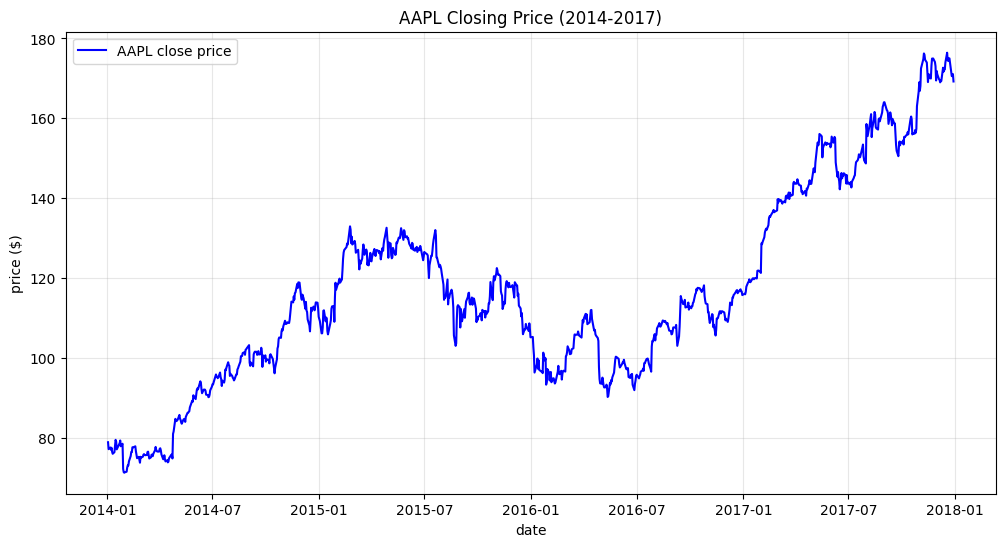

In [7]:
# Plotting the raw time series

plt.figure(figsize=(12, 6))
plt.plot(close, label='AAPL close price', color='blue')
plt.title('AAPL Closing Price (2014-2017)')
plt.xlabel('date')
plt.ylabel('price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

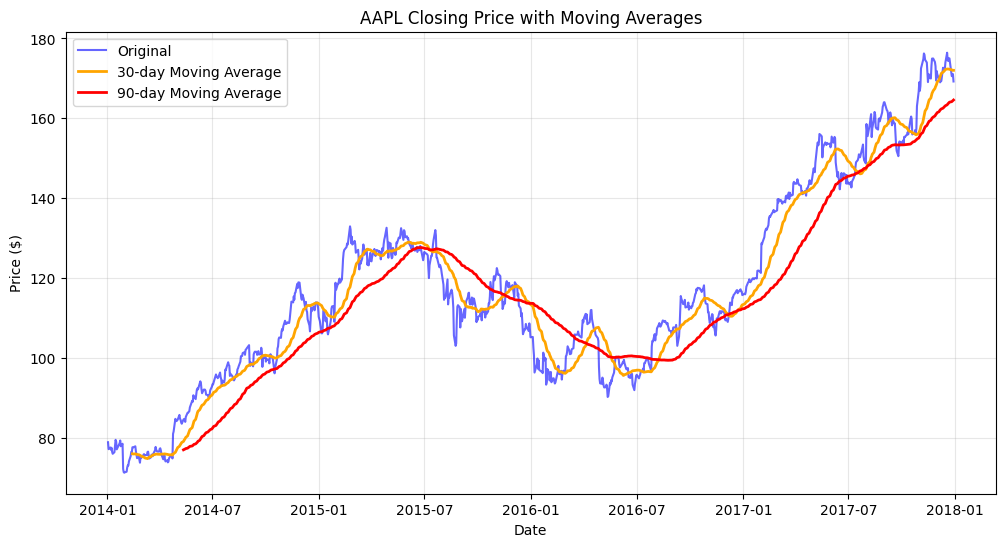

In [8]:
# Moving Average Smoothing



ma30 = close.rolling(window=30).mean()
ma90 = close.rolling(window=90).mean()


plt.figure(figsize=(12, 6))
plt.plot(close, label='Original', color='blue', alpha=0.6)
plt.plot(ma30, label='30-day Moving Average', color='orange', linewidth=2)
plt.plot(ma90, label='90-day Moving Average', color='red', linewidth=2)
plt.title('AAPL Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

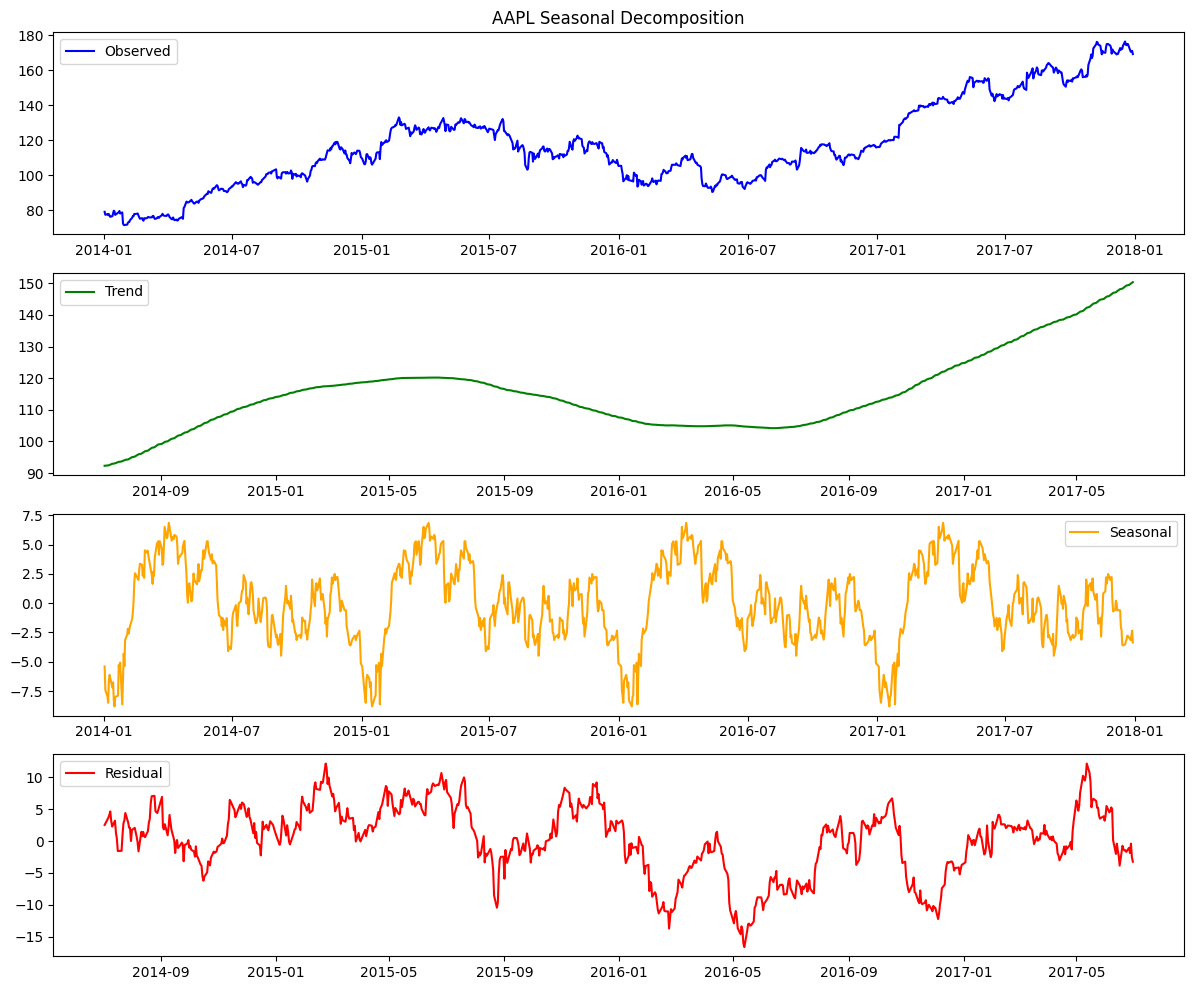

In [9]:
# Seasonal Decomposition
# period = 252 ≈ trading days in a year


decomp = seasonal_decompose(close, model='additive', period=252)

plt.figure(figsize=(12, 10))

plt.subplot(411)
plt.plot(decomp.observed, label='Observed', color='blue')
plt.title('AAPL Seasonal Decomposition')
plt.legend()

plt.subplot(412)
plt.plot(decomp.trend, label='Trend', color='green')
plt.legend()

plt.subplot(413)
plt.plot(decomp.seasonal, label='Seasonal', color='orange')
plt.legend()

plt.subplot(414)
plt.plot(decomp.resid, label='Residual', color='red')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# Summary of patterns


print("KEY FINDINGS : \n")
print("="*50)
print("• Trend: Strong upward (from ~$79 → ~$169)")
print("• Seasonality: Mild yearly cycles visible in decomposition")
print("• Residuals: Mostly random noise with occasional volatility spikes")
print("• Moving Averages: Perfectly smooth the daily fluctuations")

KEY FINDINGS : 

• Trend: Strong upward (from ~$79 → ~$169)
• Seasonality: Mild yearly cycles visible in decomposition
• Residuals: Mostly random noise with occasional volatility spikes
• Moving Averages: Perfectly smooth the daily fluctuations
